In [1]:
from sklearn.datasets import fetch_openml
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np



In [2]:
boston = fetch_openml(name="boston", version=1, as_frame=True)
df = boston.frame


In [36]:
print(df.head())

      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [37]:
df.shape

(506, 14)

In [38]:
print(df.columns)


Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')


In [39]:
for col in df.columns:
        print(f"{col} columns have {(df[col]==0).sum()} zero value")

CRIM columns have 0 zero value
ZN columns have 372 zero value
INDUS columns have 0 zero value
CHAS columns have 0 zero value
NOX columns have 0 zero value
RM columns have 0 zero value
AGE columns have 0 zero value
DIS columns have 0 zero value
RAD columns have 0 zero value
TAX columns have 0 zero value
PTRATIO columns have 0 zero value
B columns have 0 zero value
LSTAT columns have 0 zero value
MEDV columns have 0 zero value


In [40]:
df["ZN"].unique()

array([ 18. ,   0. ,  12.5,  75. ,  21. ,  90. ,  85. , 100. ,  25. ,
        17.5,  80. ,  28. ,  45. ,  60. ,  95. ,  82.5,  30. ,  22. ,
        20. ,  40. ,  55. ,  52.5,  70. ,  34. ,  33. ,  35. ])

In [41]:
df.isnull().values.any()


False

In [42]:
df.isnull().sum()


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [43]:
df[df.isnull().any(axis=1)]


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV


In [44]:
correlation_matrix = df.corr()
print(correlation_matrix)


             CRIM        ZN     INDUS      CHAS       NOX        RM       AGE  \
CRIM     1.000000 -0.200469  0.406583 -0.055892  0.420972 -0.219247  0.352734   
ZN      -0.200469  1.000000 -0.533828 -0.042697 -0.516604  0.311991 -0.569537   
INDUS    0.406583 -0.533828  1.000000  0.062938  0.763651 -0.391676  0.644779   
CHAS    -0.055892 -0.042697  0.062938  1.000000  0.091203  0.091251  0.086518   
NOX      0.420972 -0.516604  0.763651  0.091203  1.000000 -0.302188  0.731470   
RM      -0.219247  0.311991 -0.391676  0.091251 -0.302188  1.000000 -0.240265   
AGE      0.352734 -0.569537  0.644779  0.086518  0.731470 -0.240265  1.000000   
DIS     -0.379670  0.664408 -0.708027 -0.099176 -0.769230  0.205246 -0.747881   
RAD      0.625505 -0.311948  0.595129 -0.007368  0.611441 -0.209847  0.456022   
TAX      0.582764 -0.314563  0.720760 -0.035587  0.668023 -0.292048  0.506456   
PTRATIO  0.289946 -0.391679  0.383248 -0.121515  0.188933 -0.355501  0.261515   
B       -0.385064  0.175520 

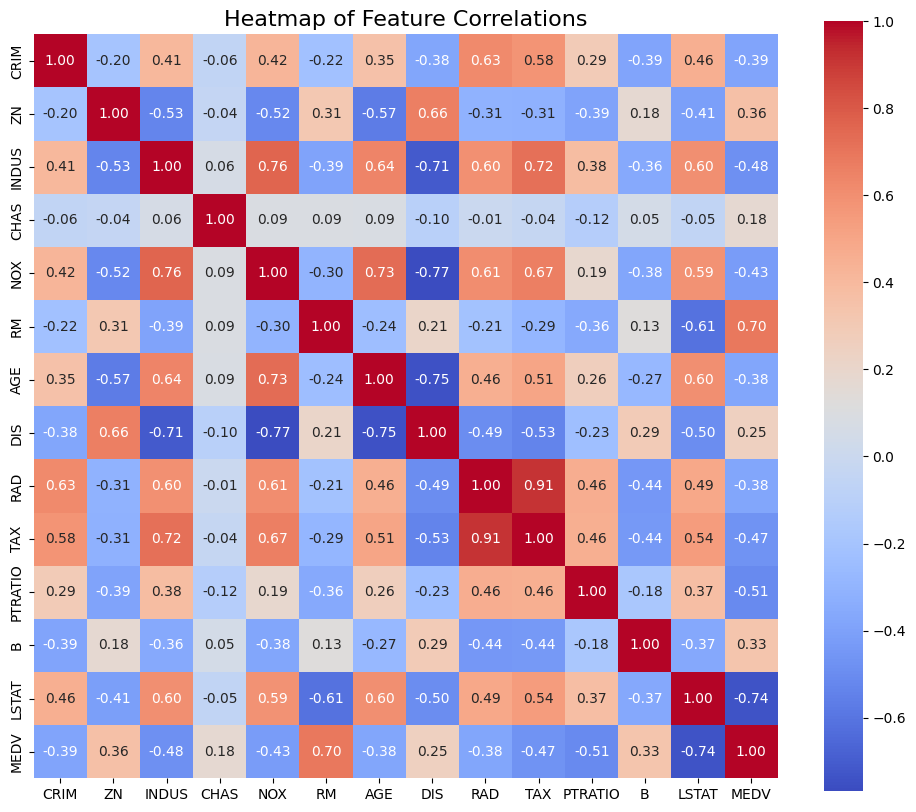

In [45]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Heatmap of Feature Correlations", fontsize=16)
plt.show()

In [46]:
X = df[["RM"]]
y = df["MEDV"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [47]:
SimpleModel = LinearRegression()
SimpleModel.fit(X_train,y_train)

LinearRegression()

In [48]:
print("Coefficient (slope):", SimpleModel.coef_)
print("Intercept (bias):", SimpleModel.intercept_)


Coefficient (slope): [9.34830141]
Intercept (bias): -36.24631889813792


In [49]:
SimpleModel.coef_

array([9.34830141])

In [50]:
y_pred_train = SimpleModel.predict(X_train)
r2 = r2_score(y_train,y_pred_train)
mae = mean_absolute_error(y_train,y_pred_train)
mse = mean_squared_error(y_train,y_pred_train)
rmse = np.sqrt(mse)
metrics = {"R^2":r2,"MAE":mae,"MSE":mse,"RMSE":rmse}

for key, value in metrics.items():
    print(f"{key} is {value}")


R^2 is 0.5050658352776293
MAE is 4.433067411904489
MSE is 42.99661556265404
RMSE is 6.557180458295626


In [51]:
y_test=SimpleModel.predict(X_test)

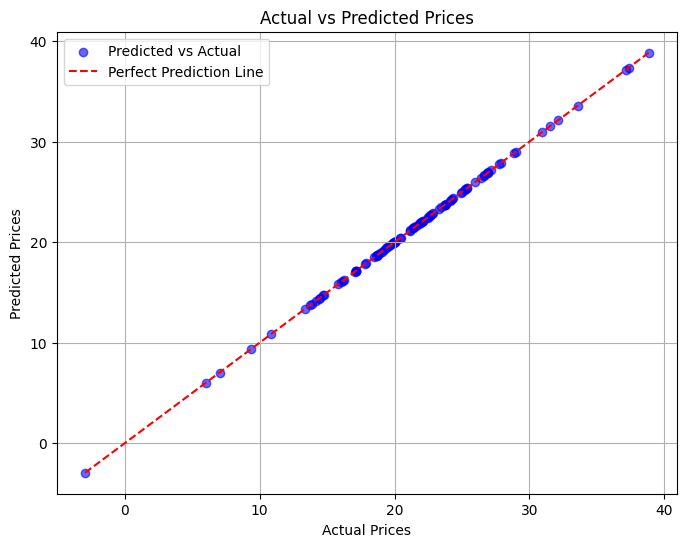

In [52]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Prediction Line')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.grid(True)
plt.show()

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


In [54]:
df["CHAS"].value_counts()


CHAS
0    471
1     35
Name: count, dtype: int64

In [55]:
df["RAD"].value_counts()


RAD
24    132
5     115
4     110
3      38
6      26
2      24
8      24
1      20
7      17
Name: count, dtype: int64

In [56]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [57]:
X = df[["RM", "LSTAT","INDUS","PTRATIO","TAX","B","NOX","ZN","DIS","AGE","CRIM"]]
y = df["MEDV"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [58]:
MRegModel1 = LinearRegression()
MRegModel1.fit(X_train, y_train)

LinearRegression()

In [59]:
print("Coefficient (slope):", MRegModel1.coef_[0])
print("Intercept (bias):", MRegModel1.intercept_)


Coefficient (slope): 4.823591355434245
Intercept (bias): 23.4951681931355


In [60]:
y_pred_train = MRegModel1.predict(X_train)
r2 = r2_score(y_train,y_pred_train)
mae = mean_absolute_error(y_train,y_pred_train)
mse = mean_squared_error(y_train,y_pred_train)
rmse = np.sqrt(mse)
metrics = {"R^2":r2,"MAE":mae,"MSE":mse,"RMSE":rmse}

for key, value in metrics.items():
    print(f"{key} is {value}")


R^2 is 0.7363405691088918
MAE is 3.3290677071807373
MSE is 22.90499221417101
RMSE is 4.785916026652684


In [61]:
y_pred = MRegModel1.predict(X_test)


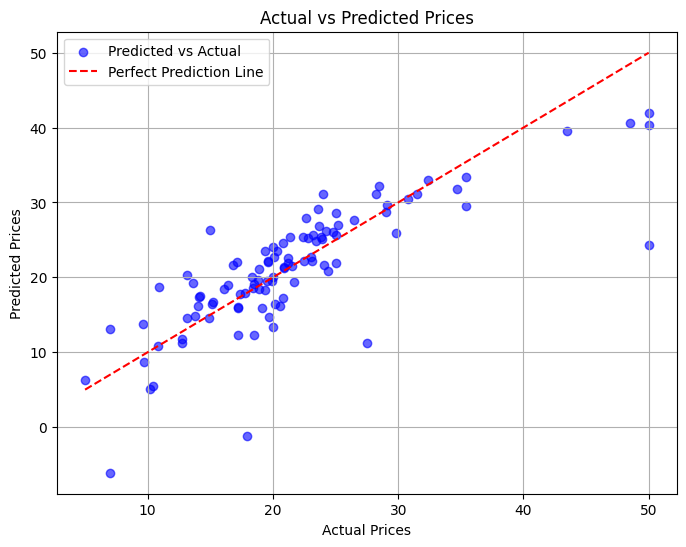

In [62]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Prediction Line')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
categorical_cols = ['CHAS', 'RAD']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [64]:
print(df_encoded.head())
print(df_encoded.info())
df_encoded.shape

      CRIM    ZN  INDUS    NOX     RM   AGE     DIS    TAX  PTRATIO       B  \
0  0.00632  18.0   2.31  0.538  6.575  65.2  4.0900  296.0     15.3  396.90   
1  0.02731   0.0   7.07  0.469  6.421  78.9  4.9671  242.0     17.8  396.90   
2  0.02729   0.0   7.07  0.469  7.185  61.1  4.9671  242.0     17.8  392.83   
3  0.03237   0.0   2.18  0.458  6.998  45.8  6.0622  222.0     18.7  394.63   
4  0.06905   0.0   2.18  0.458  7.147  54.2  6.0622  222.0     18.7  396.90   

   ...  MEDV  CHAS_1  RAD_2  RAD_24  RAD_3  RAD_4  RAD_5  RAD_6  RAD_7  RAD_8  
0  ...  24.0   False  False   False  False  False  False  False  False  False  
1  ...  21.6   False   True   False  False  False  False  False  False  False  
2  ...  34.7   False   True   False  False  False  False  False  False  False  
3  ...  33.4   False  False   False   True  False  False  False  False  False  
4  ...  36.2   False  False   False   True  False  False  False  False  False  

[5 rows x 21 columns]
<class 'pandas.core.fr

(506, 21)

In [65]:
X = df_encoded.iloc[:,:-1]
y = df.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [66]:
MRegModel2 = LinearRegression()
MRegModel2.fit(X_train, y_train)

LinearRegression()

In [67]:
print("Coefficient (slope):", MRegModel2.coef_[0])
print("Intercept (bias):", MRegModel2.intercept_)


Coefficient (slope): -2.1643294437825566e-16
Intercept (bias): 3.659295089164516e-13


In [68]:
y_pred_train = MRegModel2.predict(X_train)
r2 = r2_score(y_train,y_pred_train)
mae = mean_absolute_error(y_train,y_pred_train)
mse = mean_squared_error(y_train,y_pred_train)
rmse = np.sqrt(mse)
metrics = {"R^2":r2,"MAE":mae,"MSE":mse,"RMSE":rmse}

for key, value in metrics.items():
    print(f"{key} is {value}")


R^2 is 1.0
MAE is 3.776517052873453e-14
MSE is 3.510688774865902e-27
RMSE is 5.925106560110039e-14


In [69]:
y_pred = MRegModel2.predict(X_test)

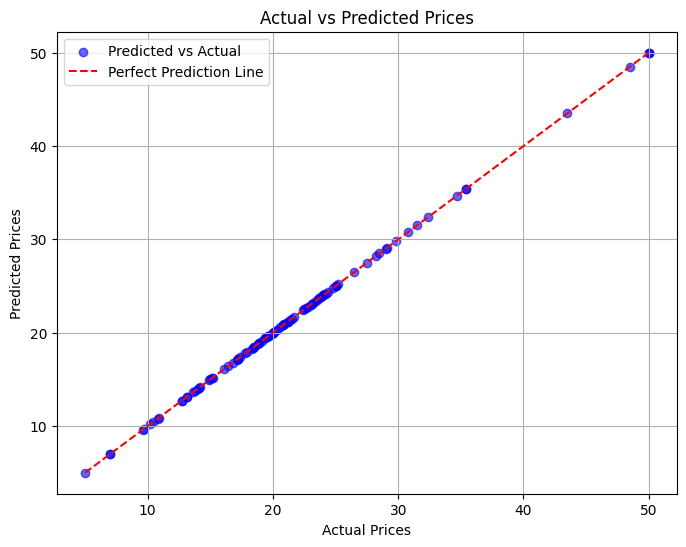

In [70]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Prediction Line')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
poly = PolynomialFeatures(degree=6)
X_poly_train = poly.fit_transform(X_train)

PRegModel = LinearRegression()
PRegModel.fit(X_poly_train, y_train)

X_poly_test = poly.transform(X_test)

y_pred_train = PRegModel.predict(X_poly_train)

y_pred_test = PRegModel.predict(X_poly_test)

MemoryError: Unable to allocate 2.67 GiB for an array with shape (404, 888030) and data type float64

In [ ]:
print("Coefficient (slope):", PRegModel.coef_[0])
print("Intercept (bias):", PRegModel.intercept_)


Coefficient (slope): -1.2108692730733682e-20
Intercept (bias): 15.384617153953846


In [ ]:
r2 = r2_score(y_train, y_pred_train)
mae = mean_absolute_error(y_train, y_pred_train)
mse = mean_squared_error(y_train, y_pred_train)
rmse = np.sqrt(mse)

print("R² score:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)


R² score: 1.0
MAE: 2.96321910903064e-11
MSE: 1.3585665537154023e-21
RMSE: 3.685873782043279e-11


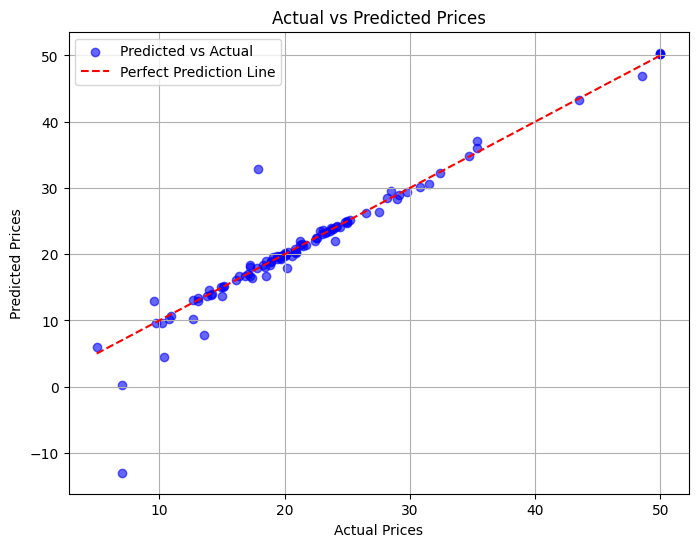

In [ ]:



plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test, color='blue', alpha=0.6, label='Predicted vs Actual')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Prediction Line')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.legend()
plt.grid(True)
plt.show()
